# Protein–Binder Interface Analysis (Optimal Binders)
Identifies surface-residue contacts between each target protein and its single optimal binder,
then compares **shape index and chemical features** (H-bond potential, PB electrostatics,
hydrophobicity) at the interface vs. the rest of the surface.

**Folder convention:**
```
PDB_ID/
  structures/   {PDB_ID}.pdb   binder.pdb   complex.pdb
  surfaces/     {PDB_ID}.ply   binder.ply   complex.ply
  surface_feat/ {PDB_ID}_input_feat.npy   binder_input_feat.npy
```
Feature NPY shape: `(N_vertices, 100, 5)`.  
NPY feature order: [0] shape index · [1] dist-dep curvature (**skipped**) · [2] H-bond · [3] PB electrostatics · [4] hydrophobicity

In [13]:
import os
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, gaussian_kde
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

try:
    import pymesh
    HAS_PYMESH = True
except ImportError:
    HAS_PYMESH = False
    print("WARNING: pymesh not found — PLY reading unavailable.")

try:
    import pyflann
    HAS_PYFLANN = True
except ImportError:
    HAS_PYFLANN = False
    print("INFO: pyflann not found — using scipy cKDTree for vertex mapping.")

try:
    from Bio.PDB import PDBParser, Selection
    HAS_BIOPDB = True
except ImportError:
    HAS_BIOPDB = False
    print("WARNING: BioPython not found.")

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.sans-serif': ['DejaVu Sans'],
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.titlesize': 10,
    'legend.fontsize': 8,
    'figure.dpi': 200,
})


## Configuration

In [29]:
BASE_DIR = "/mnt/e/pmp_targeted_drug/dryad/interfacial_feat"   # directory containing PDB_ID subdirectories

# ── interface detection ────────────────────────────────────────────────────
# A surface vertex is 'interface' when buried in the complex:
# squared distance from complex surface >= threshold (MaSIF convention).
IFACE_DIST_SQ = 2.0   # Å²  (distance ≈ 1.41 Å)
PROX_CUTOFF   = 2.5   # Å  fallback if no complex PLY

# ── features — dist-dep curvature (NPY index 1) is excluded ───────────────
FEATURE_NAMES   = ['Shape Index', 'H-Bond Potential', 'PB Electrostatics', 'Hydrophobicity']
FEATURE_INDICES = [0, 2, 3, 4]   # columns to select from the (N,5) NPY slice
FEAT_COLORS     = ['#4878CF', '#D65F5F', '#B47CC7', '#C4AD66']
N_FEAT          = len(FEATURE_NAMES)

OUT_DIR = os.path.join(BASE_DIR, 'analysis_output')
os.makedirs(OUT_DIR, exist_ok=True)

## Helper Functions

In [30]:
def read_ply(filename):
    """Read a MaSIF PLY file.  Returns (vertices, faces, normals, charge,
    vertex_cb, vertex_hbond, vertex_hphob, iface)."""
    mesh  = pymesh.load_mesh(filename)
    attrs = mesh.get_attribute_names()

    def _get(name):
        return mesh.get_attribute(name) if name in attrs else np.zeros(len(mesh.vertices))

    if 'vertex_nx' in attrs:
        normals = np.column_stack([
            mesh.get_attribute('vertex_nx'),
            mesh.get_attribute('vertex_ny'),
            mesh.get_attribute('vertex_nz'),
        ])
    else:
        normals = None

    return (
        mesh.vertices, mesh.faces, normals,
        _get('vertex_charge'), _get('vertex_cb'),
        _get('vertex_hbond'),  _get('vertex_hphob'), _get('vertex_iface'),
    )


def compute_AtomRes_per_vertex(pdb_path, vertices):
    """Assign nearest heavy-atom name and residue label to each surface vertex.
    Uses pyflann when available, falls back to scipy cKDTree."""
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure('X', pdb_path)
    WATER  = {'HOH', 'WAT', 'TIP3', 'SOL'}
    heavy  = [
        at for at in Selection.unfold_entities(struct, 'A')
        if at.element != 'H' and at.get_parent().get_resname() not in WATER
    ]

    at_coord = np.array([at.get_coord() for at in heavy], dtype=float)
    verts    = np.array(vertices, dtype=float)

    if HAS_PYFLANN:
        flann = pyflann.FLANN()
        nn_idx, _ = flann.nn(at_coord, verts)
    else:
        _, nn_idx = cKDTree(at_coord).query(verts)

    vert_atom, vert_res = [], []
    for ix in range(len(verts)):
        at  = heavy[nn_idx[ix]]
        res = at.get_parent()
        vert_atom.append(at.get_name())
        vert_res.append(f"{res.get_resname()}_{res.get_id()[1]}")
    return vert_atom, vert_res


def interface_mask_complex(indiv_verts, complex_verts, dist_sq=IFACE_DIST_SQ):
    """MaSIF-style: vertex is interface when buried (d² >= dist_sq from complex surface)."""
    d, _ = cKDTree(complex_verts).query(indiv_verts)
    return d ** 2 >= dist_sq


def interface_mask_proximity(target_verts, binder_verts, cutoff=PROX_CUTOFF):
    """Fallback: vertices within cutoff Å of the other protein."""
    t_mask = cKDTree(binder_verts).query(target_verts)[0] <= cutoff
    b_mask = cKDTree(target_verts).query(binder_verts)[0] <= cutoff
    return t_mask, b_mask


def feat_vec(npy_path):
    """Load NPY and return (N, 4) array of selected features for each vertex."""
    arr = np.load(npy_path)          # (N, 100, 5)
    return arr[:, 0, :][:, FEATURE_INDICES]   # center-patch vertex, 4 features

## Dataset Discovery

In [31]:
def discover_datasets(base_dir):
    datasets = {}
    for pdb_id in sorted(os.listdir(base_dir)):
        pd_dir = os.path.join(base_dir, pdb_id)
        if not os.path.isdir(pd_dir):
            continue
        sd = os.path.join(pd_dir, 'structures')
        sv = os.path.join(pd_dir, 'surfaces')
        sf = os.path.join(pd_dir, 'surface_feat')
        if not all(os.path.isdir(d) for d in [sd, sv, sf]):
            continue

        def p(folder, name): return os.path.join(pd_dir, folder, name)

        entry = {
            'target': {
                'pdb': p('structures', f'{pdb_id}.pdb'),
                'ply': p('surfaces',   f'{pdb_id}.ply'),
                'npy': p('surface_feat', f'{pdb_id}_input_feat.npy'),
            },
            'binder': {
                'pdb':         p('structures',   'binder.pdb'),
                'ply':         p('surfaces',     'binder.ply'),
                'npy':         p('surface_feat', 'binder_input_feat.npy'),
                'complex_ply': p('surfaces',     'complex.ply'),
            },
        }
        # verify required files exist
        required = [
            entry['target']['pdb'], entry['target']['ply'], entry['target']['npy'],
            entry['binder']['pdb'], entry['binder']['ply'], entry['binder']['npy'],
        ]
        if all(os.path.exists(f) for f in required):
            datasets[pdb_id] = entry
    return datasets


datasets = discover_datasets(BASE_DIR)
print(f"Found {len(datasets)} PDB entries: {list(datasets.keys())}")
for pid, ds in datasets.items():
    has_cx = os.path.exists(ds['binder']['complex_ply'])
    print(f"  {pid}  complex PLY: {'yes' if has_cx else 'NO — will use proximity fallback'}")

Found 3 PDB entries: ['1CZT', '2B0M', '2OBI']
  1CZT  complex PLY: yes
  2B0M  complex PLY: yes
  2OBI  complex PLY: yes


## Interface Detection & Feature Extraction
For each target–binder pair:
1. Load PLY surfaces; compute interface mask from the complex PLY (MaSIF buried-vertex method).
2. Map interface vertices to residues via nearest heavy atom.
3. Extract `(N, 4)` feature vectors — shape index + 3 chemical features — skipping dist-dep curvature.

In [32]:
all_records   = []
iface_summary = []

for pdb_id, ds in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {pdb_id}")
    print(f"{'='*60}")

    t = ds['target']
    b = ds['binder']

    # ── surfaces ────────────────────────────────────────────────────
    t_verts, *_ = read_ply(t['ply'])
    b_verts, *_ = read_ply(b['ply'])

    # ── features (N, 4) — shape + chemical only ──────────────────────
    t_fv = feat_vec(t['npy'])   # (N_t, 4)
    b_fv = feat_vec(b['npy'])   # (N_b, 4)

    # ── residue mapping ──────────────────────────────────────────────
    t_atom, t_res = compute_AtomRes_per_vertex(t['pdb'], t_verts)
    b_atom, b_res = compute_AtomRes_per_vertex(b['pdb'], b_verts)
    t_res = np.array(t_res)
    b_res = np.array(b_res)

    # ── interface masks ──────────────────────────────────────────────
    if os.path.exists(b['complex_ply']):
        c_verts, *_ = read_ply(b['complex_ply'])
        t_mask = interface_mask_complex(t_verts, c_verts)
        b_mask = interface_mask_complex(b_verts, c_verts)
        method = 'complex-surface (MaSIF)'
    else:
        t_mask, b_mask = interface_mask_proximity(t_verts, b_verts)
        method = f'proximity ({PROX_CUTOFF} Å fallback)'

    print(f"  method  : {method}")
    print(f"  target  : {t_mask.sum():4d} / {len(t_mask)} interface vertices")
    print(f"  binder  : {b_mask.sum():4d} / {len(b_mask)} interface vertices")

    # ── interface residues ───────────────────────────────────────────
    t_iface_res = sorted(set(t_res[t_mask]))
    b_iface_res = sorted(set(b_res[b_mask]))

    print(f"\n  TARGET ({pdb_id}) interface residues ({len(t_iface_res)}):")
    for i in range(0, len(t_iface_res), 10):
        print("   ", ", ".join(t_iface_res[i:i+10]))

    print(f"\n  BINDER interface residues ({len(b_iface_res)}):")
    for i in range(0, len(b_iface_res), 10):
        print("   ", ", ".join(b_iface_res[i:i+10]))

    iface_summary.append({
        'pdb_id':              pdb_id,
        'n_target_iface_verts': int(t_mask.sum()),
        'n_binder_iface_verts': int(b_mask.sum()),
        'n_target_iface_res':   len(t_iface_res),
        'n_binder_iface_res':   len(b_iface_res),
        'target_iface_res':     t_iface_res,
        'binder_iface_res':     b_iface_res,
    })

    # ── store per-vertex records ─────────────────────────────────────
    for role, verts, mask, res_arr, atom_arr, fv in [
        ('target', t_verts, t_mask, t_res, t_atom, t_fv),
        ('binder', b_verts, b_mask, b_res, b_atom, b_fv),
    ]:
        for vi in range(len(verts)):
            rec = {
                'pdb_id': pdb_id, 'role': role,
                'vertex_idx': vi,
                'residue': res_arr[vi], 'atom': atom_arr[vi],
                'is_interface': bool(mask[vi]),
            }
            for fi, fn in enumerate(FEATURE_NAMES):
                rec[fn] = float(fv[vi, fi])
            all_records.append(rec)

print("\nDone.")
df = pd.DataFrame(all_records)
print(f"Total vertex records : {len(df):,}")
print(f"Interface vertices   : {df.is_interface.sum():,}")
df.head()


  1CZT
  method  : complex-surface (MaSIF)
  target  : 3293 / 3293 interface vertices
  binder  :  178 / 1641 interface vertices

  TARGET (1CZT) interface residues (139):
    ALA_19, ALA_40, ALA_49, ALA_51, ALA_70, ARG_103, ARG_134, ARG_137, ARG_150, ARG_35
    ARG_37, ARG_43, ASN_116, ASN_118, ASN_125, ASN_128, ASN_14, ASN_144, ASN_39, ASN_45
    ASN_52, ASN_53, ASN_54, ASN_9, ASP_110, ASP_157, ASP_29, ASP_61, CYS_1, CYS_156
    CYS_76, GLN_145, GLN_16, GLN_41, GLN_48, GLN_56, GLN_74, GLN_95, GLU_114, GLU_13
    GLU_152, GLU_32, GLU_59, GLU_8, GLU_82, GLU_94, GLU_98, GLY_0, GLY_10, GLY_115
    GLY_121, GLY_155, GLY_28, GLY_42, GLY_96, HIS_122, HIS_91, ILE_112, ILE_12, ILE_131
    ILE_132, ILE_139, ILE_158, ILE_17, ILE_65, ILE_72, LEU_104, LEU_38, LEU_5, LEU_62
    LEU_63, LEU_79, LYS_100, LYS_105, LYS_11, LYS_111, LYS_120, LYS_124, LYS_141, LYS_15
    LYS_23, LYS_24, LYS_50, LYS_55, LYS_64, LYS_66, LYS_67, LYS_77, LYS_86, MET_108
    MET_7, MET_83, PHE_113, PHE_126, PHE_127, PHE_135

  method  : complex-surface (MaSIF)
  target  :  374 / 6543 interface vertices
  binder  :  188 / 1585 interface vertices

  TARGET (2B0M) interface residues (57):
    ALA_348, ARG_160, ARG_162, ARG_245, ARG_318, ARG_347, ARG_57, ARG_61, ARG_70, ASN_150
    ASP_207, ASP_393, GLU_103, GLU_158, GLU_53, GLY_153, GLY_33, GLY_391, GLY_97, HSD_101
    HSD_152, HSD_159, HSD_248, HSD_394, HSD_41, HSD_56, HSD_86, LEU_42, LEU_46, LEU_49
    LEU_50, LEU_58, LEU_65, LEU_67, LEU_68, LEU_84, LYS_100, LYS_87, PHE_37, PHE_62
    PHE_88, PHE_98, PRO_177, PRO_204, PRO_69, SER_151, SER_155, THR_172, THR_45, TYR_147
    TYR_208, TYR_321, TYR_38, VAL_156, VAL_157, VAL_60, VAL_83

  BINDER interface residues (19):
    ALA_413, ALA_414, ALA_451, ALA_458, ALA_462, ALA_463, ARG_467, ASP_452, GLU_460, GLY_417
    GLY_448, ILE_410, LEU_406, LEU_418, LEU_455, LEU_456, LEU_459, LEU_466, PRO_447

  2OBI
  method  : complex-surface (MaSIF)
  target  : 3134 / 3134 interface vertices
  binder  :  255 / 1489 interface 

,pdb_id,role,vertex_idx,residue,atom,is_interface,Shape Index,H-Bond Potential,PB Electrostatics,Hydrophobicity
0,1CZT,target,0,TRP_26,CB,True,0.124562,0.00000,0.134154,-0.200000
1,1CZT,target,1,LEU_79,O,True,0.596121,0.00000,0.059604,0.844444
2,1CZT,target,2,TRP_143,CE2,True,-0.451729,0.00000,-0.027920,-0.200000
3,1CZT,target,3,GLU_98,OE1,True,0.999891,-0.16364,-0.393153,-0.777778
4,1CZT,target,4,PHE_135,CZ,True,-0.525881,0.00000,-0.070330,0.533524


## Interface Residue Summary

In [33]:
summary_df = pd.DataFrame(iface_summary).drop(
    columns=['target_iface_res', 'binder_iface_res'])
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(OUT_DIR, 'interface_residue_counts.csv'), index=False)

# full residue lists
rows = []
for entry in iface_summary:
    for res in entry['target_iface_res']:
        rows.append({'pdb_id': entry['pdb_id'], 'role': 'target', 'residue': res})
    for res in entry['binder_iface_res']:
        rows.append({'pdb_id': entry['pdb_id'], 'role': 'binder', 'residue': res})
res_df = pd.DataFrame(rows)
res_df.to_csv(os.path.join(OUT_DIR, 'interface_residues.csv'), index=False)
print(f"\nSaved {len(res_df)} residue entries → interface_residues.csv")

pdb_id  n_target_iface_verts  n_binder_iface_verts  n_target_iface_res  n_binder_iface_res
  1CZT                  3293                   178                 139                  17
  2B0M                   374                   188                  57                  19
  2OBI                  3134                   255                 134                  24

Saved 390 residue entries → interface_residues.csv


## Feature Analysis
### 1 · PMP Target vs. Binder Interface Feature Distributions
Violin + box plot for each of the 4 features, split by role and interface flag.

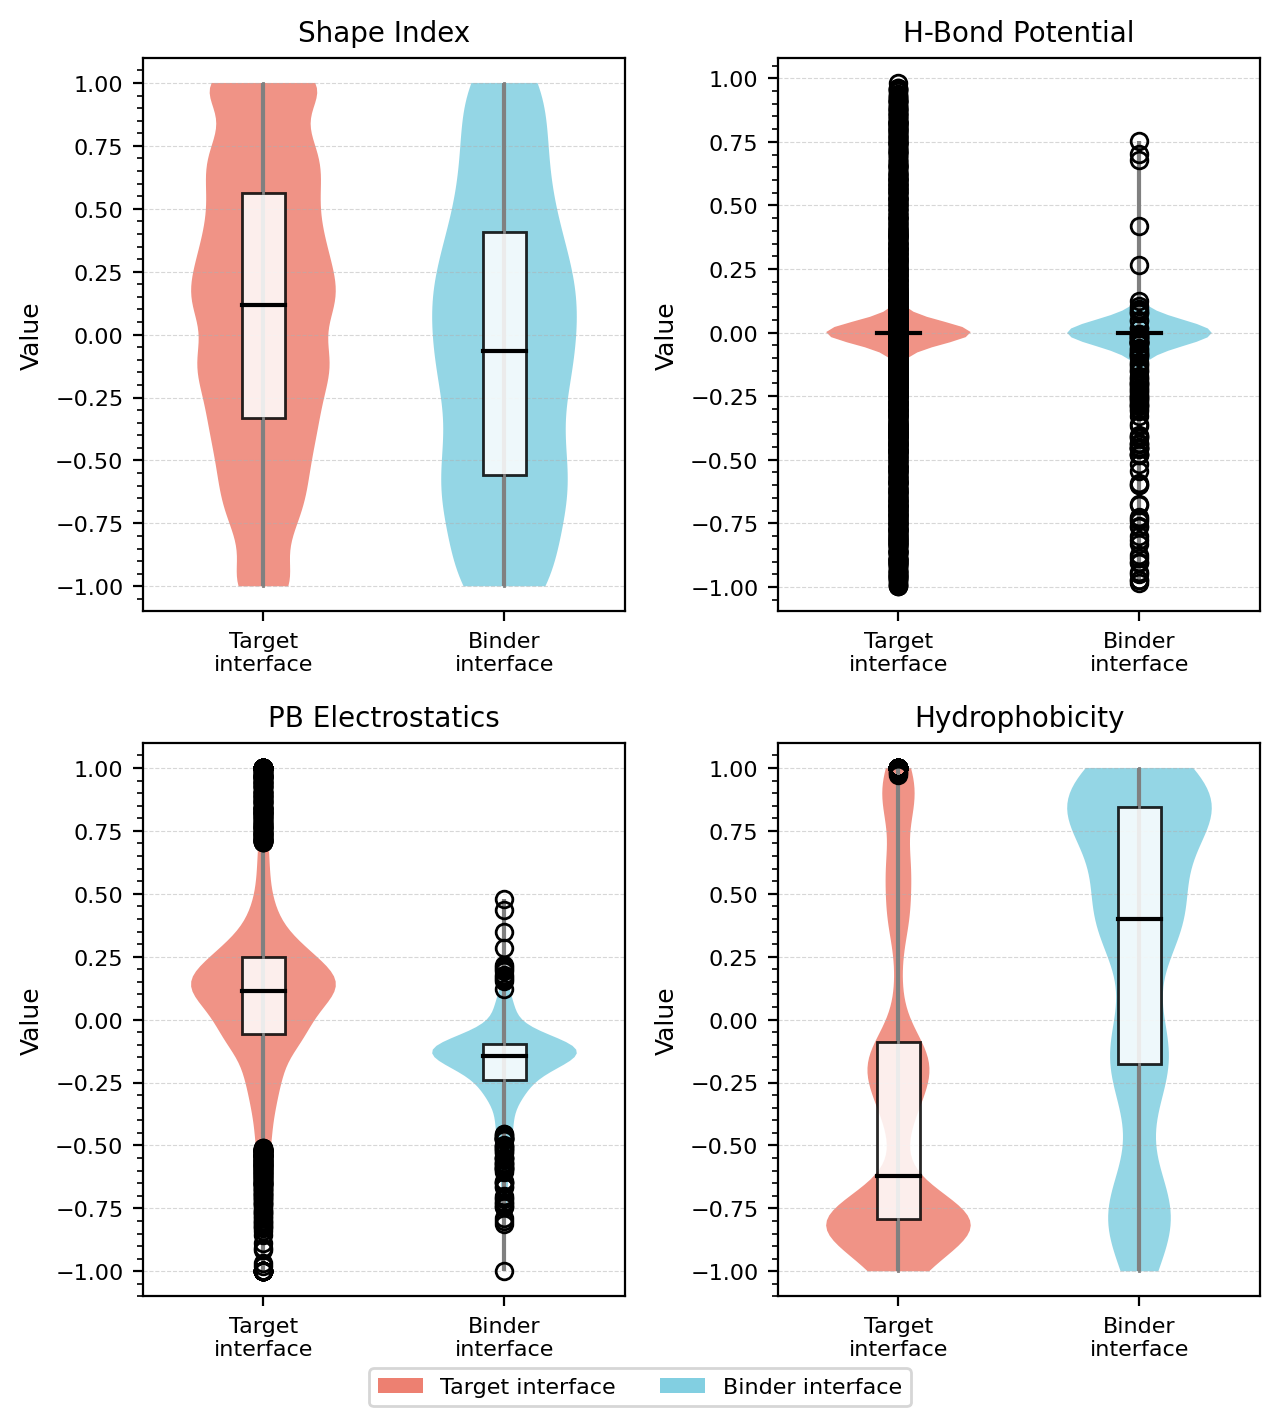

In [34]:
PALETTE = {'target': '#E64B35', 'binder': '#4DBBD5'}

iface_df = df[df.is_interface]

fig, axes = plt.subplots(2, 2, figsize=(6.5, 7), sharey=False)

for ax, fname in zip(axes.flatten(), FEATURE_NAMES):
    groups = [
        iface_df.loc[iface_df.role == 'target', fname].dropna().values,
        iface_df.loc[iface_df.role == 'binder', fname].dropna().values,
    ]
    labels = ['Target\ninterface', 'Binder\ninterface']
    colors = [PALETTE['target'], PALETTE['binder']]
    xticks = [0, 1]

    vp = ax.violinplot(groups, positions=xticks, showmedians=False, widths=0.6)
    for body, col in zip(vp['bodies'], colors):
        body.set_facecolor(col)
        body.set_alpha(0.6)
    for part in ('cmins', 'cmaxes'):
        vp[part].set_visible(False)
    vp['cbars'].set_color('gray')

    ax.boxplot(groups, positions=xticks, widths=0.18, patch_artist=True,
               showcaps=False,
               medianprops=dict(color='black', linewidth=1.5),
               whiskerprops=dict(color='gray'),
               boxprops=dict(facecolor='white', alpha=0.85))

    ax.set_xticks(xticks)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(fname, ) #fontweight='bold'
    ax.set_ylabel('Value')
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis='y', linewidth=0.4, linestyle='--', alpha=0.5)

fig.legend(handles=[
    Patch(facecolor=PALETTE['target'], alpha=0.7, label='Target interface'),
    Patch(facecolor=PALETTE['binder'], alpha=0.7, label='Binder interface'),
], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))
# fig.suptitle('Interface Feature Distributions — Target vs. Binder',
#              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig1_iface_vs_surface.png'), bbox_inches='tight', dpi=300)
plt.show()

### 2 · Interface Feature Histograms — Target vs. Binder
KDE-overlaid histograms for interface vertices only.

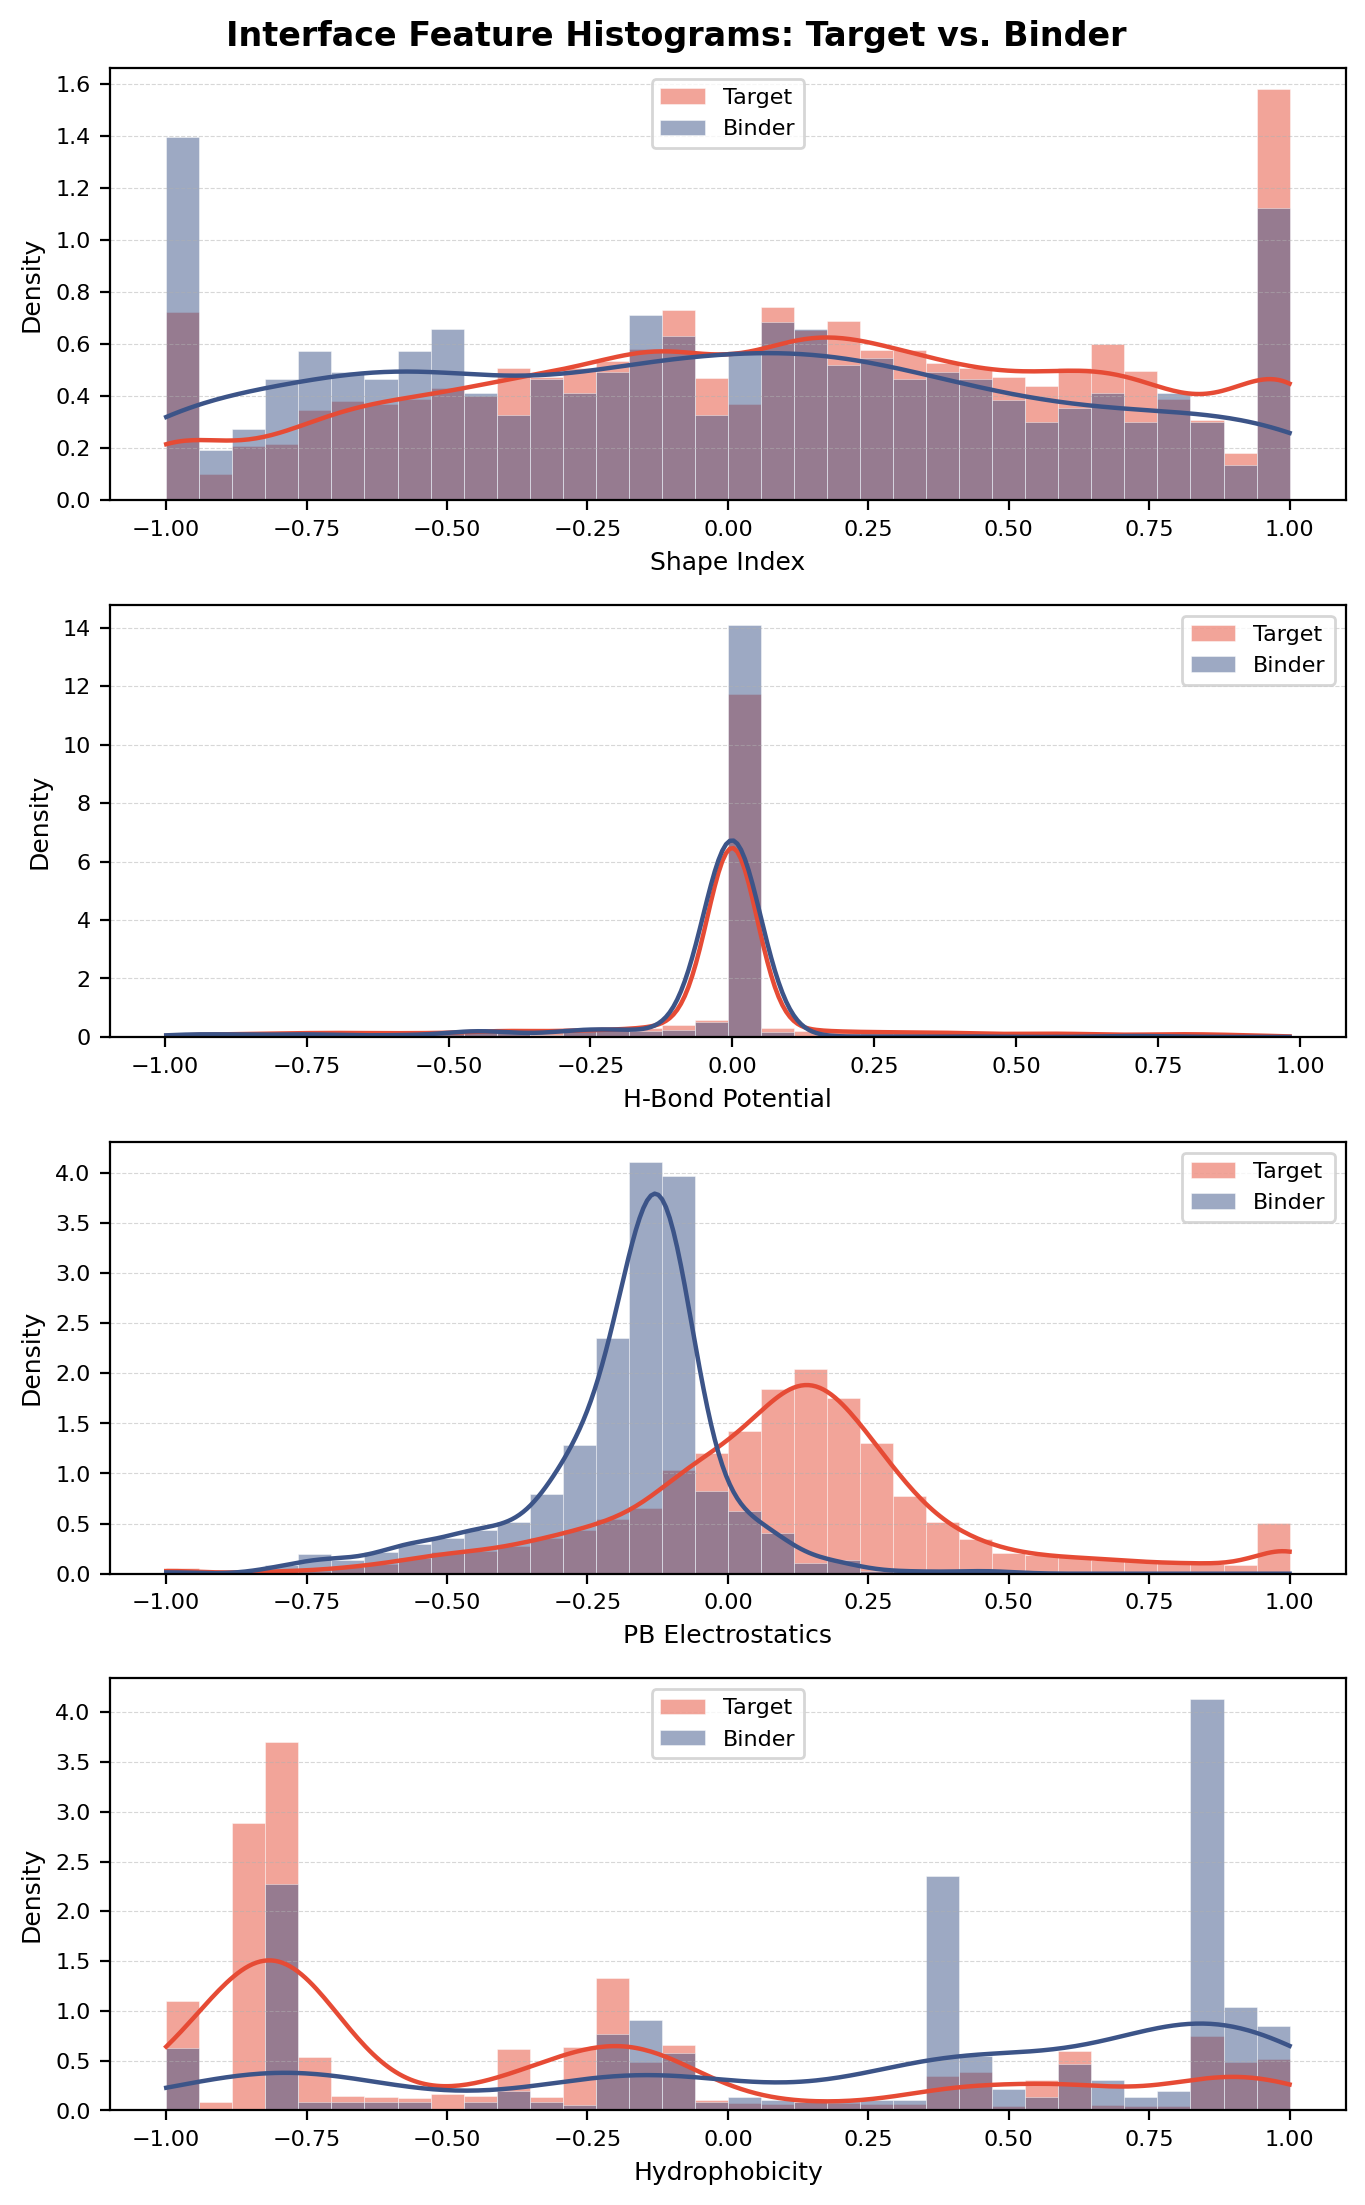

In [35]:
iface_df = df[df.is_interface]

fig, axes = plt.subplots(N_FEAT, 1, figsize=(7, 2.8 * N_FEAT))
if N_FEAT == 1:
    axes = [axes]

for ax, fname in zip(axes, FEATURE_NAMES):
    t_vals = iface_df.loc[iface_df.role == 'target', fname].dropna()
    b_vals = iface_df.loc[iface_df.role == 'binder', fname].dropna()
    bins = np.linspace(min(t_vals.min(), b_vals.min()),
                       max(t_vals.max(), b_vals.max()), 35)

    ax.hist(t_vals, bins=bins, density=True, alpha=0.5,
            color='#E64B35', label='Target', edgecolor='white', linewidth=0.3)
    ax.hist(b_vals, bins=bins, density=True, alpha=0.5,
            color='#3C5488', label='Binder', edgecolor='white', linewidth=0.3)

    xg = np.linspace(bins[0], bins[-1], 300)
    for vals, col in [(t_vals, '#E64B35'), (b_vals, '#3C5488')]:
        if len(vals) > 5:
            ax.plot(xg, gaussian_kde(vals)(xg), color=col, linewidth=1.6)

    ax.set_xlabel(fname)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(axis='y', linewidth=0.4, linestyle='--', alpha=0.5)

fig.suptitle('Interface Feature Histograms: Target vs. Binder',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig2_interface_histograms.png'), bbox_inches='tight', dpi=200)
plt.show()

### 3 · Per-PDB Interface Feature Profile
Mean ± SD of each feature at the interface for every PDB entry.

pdb_id   role  Shape Index_mean  Shape Index_std  H-Bond Potential_mean  H-Bond Potential_std  PB Electrostatics_mean  PB Electrostatics_std  Hydrophobicity_mean  Hydrophobicity_std
  1CZT binder         -0.000496         0.606642              -0.066106              0.238853               -0.190524               0.231115             0.102223            0.588991
  1CZT target          0.122873         0.557369              -0.016258              0.262545                0.171235               0.280772            -0.335455            0.603285
  2B0M binder         -0.011432         0.594764              -0.013237              0.066812               -0.135177               0.128722             0.392877            0.622767
  2B0M target         -0.173287         0.550272              -0.024020              0.163137                0.162281               0.531986             0.138684            0.694644
  2OBI binder         -0.109992         0.580750              -0.067454              0.191

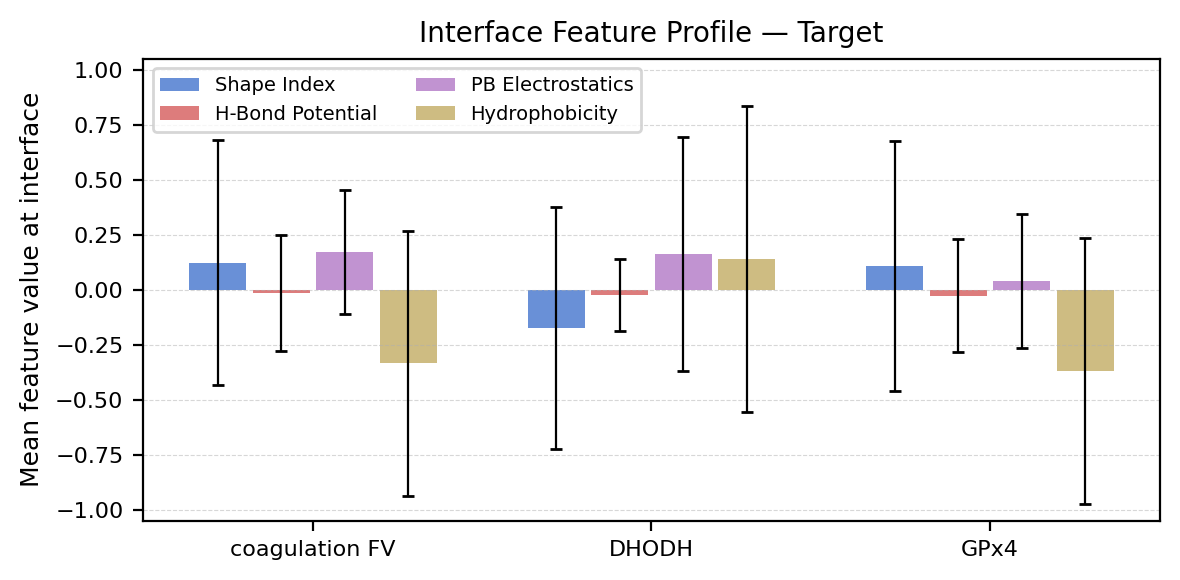

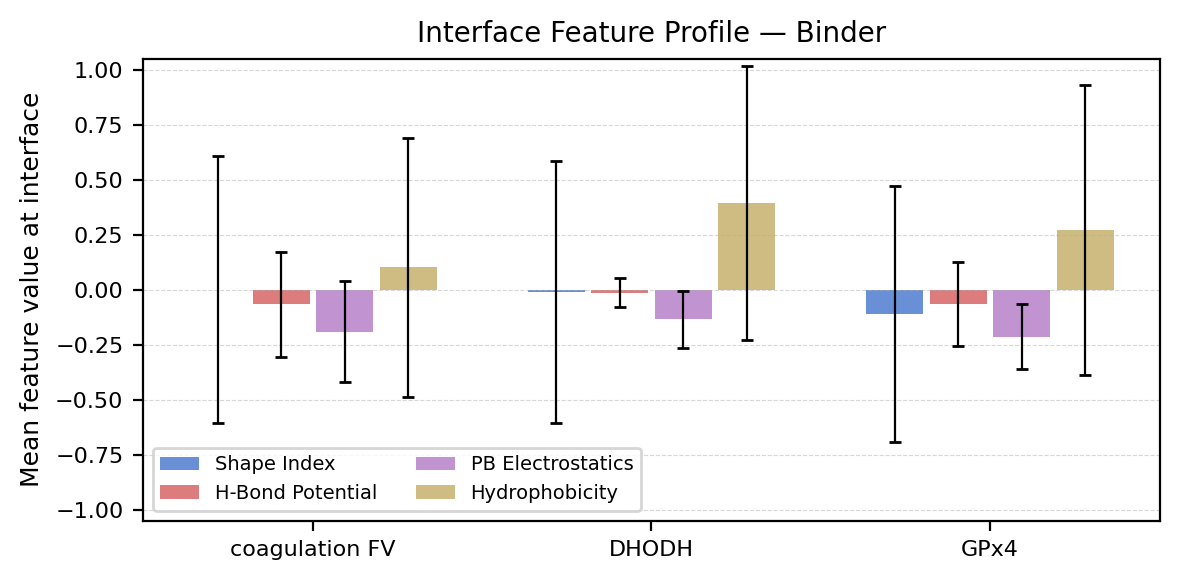

In [36]:
ptn_name_dic = {
    "1CZT":"coagulation FV",
    "2B0M":"DHODH",
    "2OBI":"GPx4"
}

agg = (
    df[df.is_interface]
    .groupby(['pdb_id', 'role'])[FEATURE_NAMES]
    .agg(['mean', 'std'])
)
agg.columns = ['_'.join(c) for c in agg.columns]
agg = agg.reset_index()
print(agg.to_string(index=False))
agg.to_csv(os.path.join(OUT_DIR, 'interface_feature_stats.csv'), index=False)

# grouped bar chart
for role in ['target', 'binder']:
    sub = agg[agg.role == role].set_index('pdb_id')
    pdb_ids = sub.index.tolist()
    x = np.arange(len(pdb_ids))
    w = 0.75 / N_FEAT

    fig, ax = plt.subplots(figsize=(max(4, 2 * len(pdb_ids)), 3))
    for fi, (fname, fc) in enumerate(zip(FEATURE_NAMES, FEAT_COLORS)):
        offset = (fi - N_FEAT / 2 + 0.5) * w
        ax.bar(x + offset, sub[f'{fname}_mean'], w * 0.9,
               yerr=sub[f'{fname}_std'], label=fname, color=fc, alpha=0.82,
               error_kw=dict(elinewidth=0.8, capsize=2))

    ax.set_xticks(x)
    ax.set_xticklabels([ptn_name_dic[pdb_id] for pdb_id in pdb_ids])
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel('Mean feature value at interface')
    ax.set_title(f'Interface Feature Profile — {role.capitalize()}')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(axis='y', linewidth=0.4, linestyle='--', alpha=0.5)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f'fig3_{role}_profile.png'), bbox_inches='tight', dpi=300)
    plt.show()

### 4 · Feature Correlation at the Interface

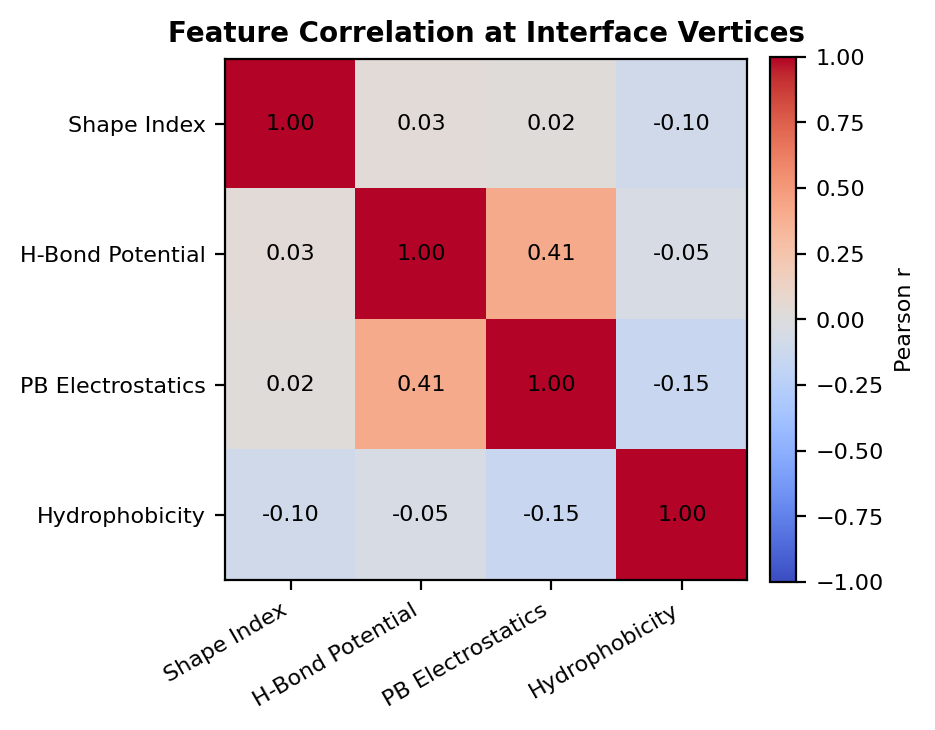

In [37]:
corr = iface_df[FEATURE_NAMES].corr()

fig, ax = plt.subplots(figsize=(4.5, 3.8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(N_FEAT)); ax.set_xticklabels(FEATURE_NAMES, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(N_FEAT)); ax.set_yticklabels(FEATURE_NAMES, fontsize=8)
for r in range(N_FEAT):
    for c in range(N_FEAT):
        ax.text(c, r, f'{corr.iloc[r,c]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Pearson r', fontsize=8)
ax.set_title('Feature Correlation at Interface Vertices', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig4_feature_correlation.png'), bbox_inches='tight', dpi=200)
plt.show()

### 5 · Radar Chart — Normalised Interface Feature Profile per PDB

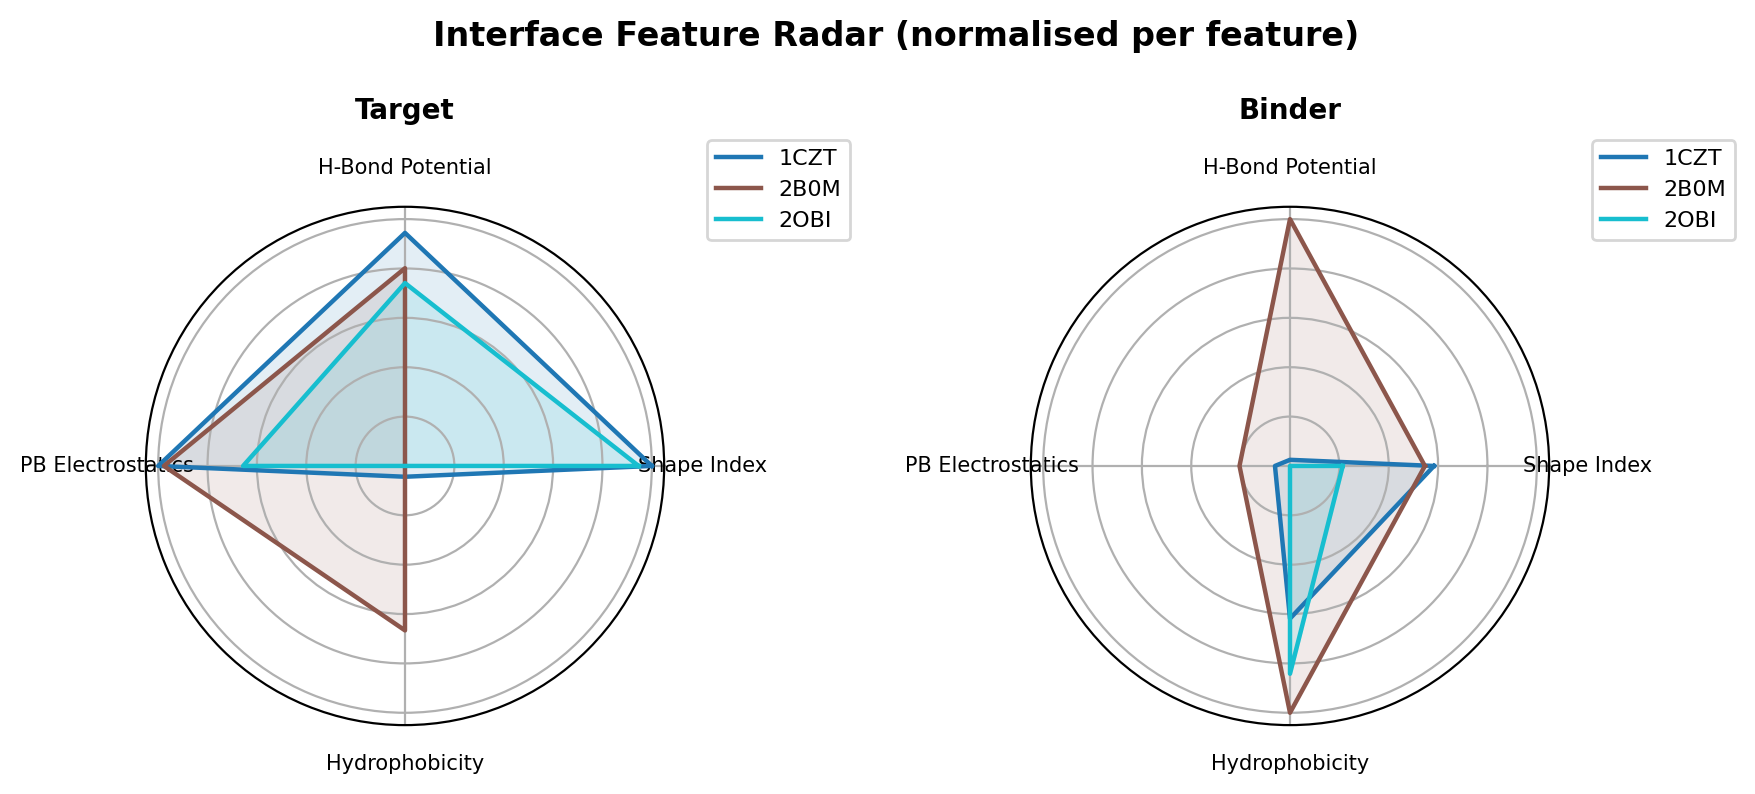

In [38]:
iface_means = (
    df[df.is_interface]
    .groupby(['pdb_id', 'role'])[FEATURE_NAMES].mean()
)
feat_min = iface_means.min()
feat_max = iface_means.max()
iface_norm = (iface_means - feat_min) / (feat_max - feat_min + 1e-9)

pdb_list   = iface_norm.index.get_level_values('pdb_id').unique().tolist()
colors_cyc = plt.cm.tab10(np.linspace(0, 1, len(pdb_list)))

angles = np.linspace(0, 2 * np.pi, N_FEAT, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(9, 4), subplot_kw=dict(polar=True))
for ax, role in zip(axes, ['target', 'binder']):
    for pid, col in zip(pdb_list, colors_cyc):
        if (pid, role) not in iface_norm.index:
            continue
        vals = iface_norm.loc[(pid, role), FEATURE_NAMES].values.tolist()
        vals += vals[:1]
        ax.plot(angles, vals, color=col, linewidth=1.6, label=pid)
        ax.fill(angles, vals, color=col, alpha=0.12)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(FEATURE_NAMES, fontsize=7.5)
    ax.set_yticklabels([])
    ax.set_title(role.capitalize(), fontsize=10, fontweight='bold', pad=14)
    ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.15), fontsize=8)

fig.suptitle('Interface Feature Radar (normalised per feature)', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig5_radar_chart.png'), bbox_inches='tight', dpi=200)
plt.show()

### 6 · Residue-Level Feature Table

In [39]:
res_feat = (
    df[df.is_interface]
    .groupby(['pdb_id', 'role', 'residue'])[FEATURE_NAMES]
    .mean()
    .reset_index()
)
res_feat.to_csv(os.path.join(OUT_DIR, 'residue_interface_features.csv'), index=False)
print(f"Saved {len(res_feat)} residue-level feature rows.")
res_feat.head(15)

Saved 390 residue-level feature rows.


,pdb_id,role,residue,Shape Index,H-Bond Potential,PB Electrostatics,Hydrophobicity
0,1CZT,binder,ALA_5,-0.758390,0.000000,0.040058,0.400000
1,1CZT,binder,ALA_73,0.085996,-0.031271,-0.159813,0.419681
2,1CZT,binder,ALA_74,-0.438523,0.019450,-0.101690,0.161974
3,1CZT,binder,ALA_76,0.306135,-0.217020,-0.331199,0.320550
4,1CZT,binder,ASN_53,-0.399632,-0.041268,-0.293091,-0.664928
5,1CZT,binder,GLN_57,0.168420,-0.087290,-0.195098,-0.777778
6,1CZT,binder,GLU_75,0.152090,-0.076700,-0.363669,-0.582923
7,1CZT,binder,ILE_2,0.351178,-0.113671,-0.139453,0.673619
8,1CZT,binder,ILE_70,-0.447576,0.000000,-0.102955,0.834894
9,1CZT,binder,LEU_4,-0.180365,0.000000,-0.094096,0.676278


### 7 · Amino Acid Propensity at the Interface

For each role (target / binder) we compute the **interface propensity** of every amino acid type:

$$P(AA) = \frac{f_\text{interface}(AA)}{f_\text{surface}(AA)}$$

where $f$ is the fraction of **unique residues** of that type (one residue counted once regardless of how many surface vertices it has).  
$P > 1$ → enriched at the interface; $P < 1$ → depleted.

  role aa  n_surface  n_interface  f_surface  f_interface  propensity
target  A         37           14     0.0646       0.0424      0.6570
target  C          8            8     0.0140       0.0242      1.7364
target  D         35           17     0.0611       0.0515      0.8434
target  E         40           22     0.0698       0.0667      0.9550
target  F         25           19     0.0436       0.0576      1.3196
target  G         51           23     0.0890       0.0697      0.7831
target  H         15           15     0.0262       0.0455      1.7364
target  I         19           16     0.0332       0.0485      1.4622
target  K         49           34     0.0855       0.1030      1.2048
target  L         39           18     0.0681       0.0545      0.8014
target  M          9            6     0.0157       0.0182      1.1576
target  N         29           21     0.0506       0.0636      1.2574
target  P         29           14     0.0506       0.0424      0.8382
target  Q         28

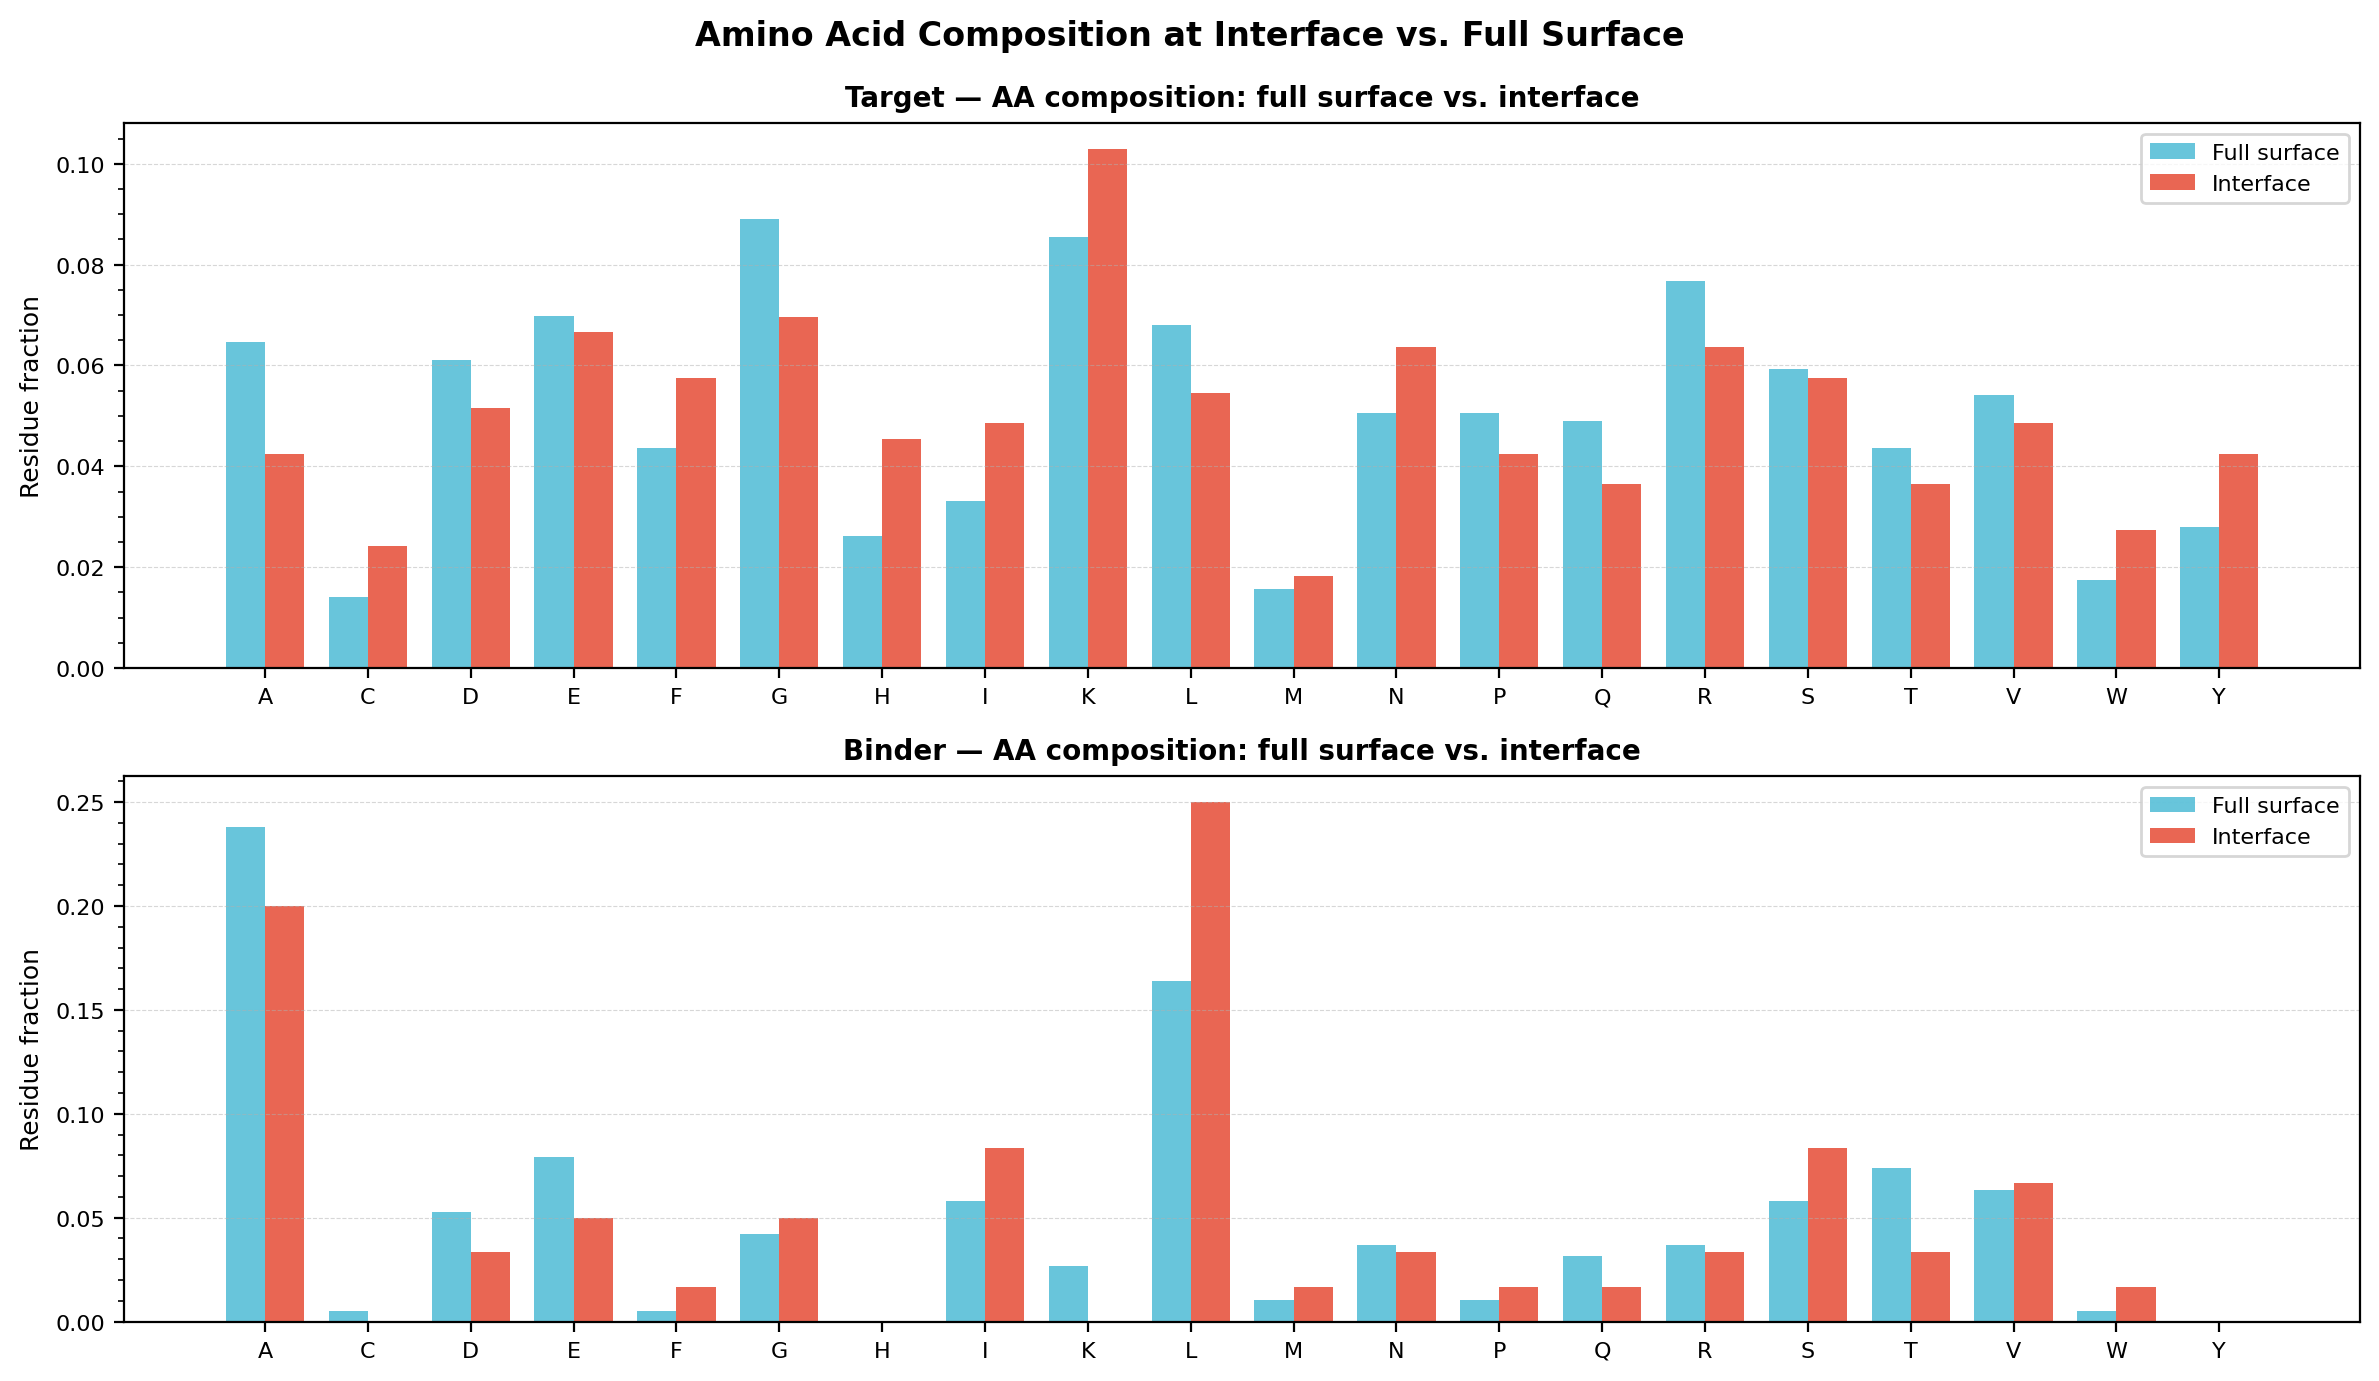

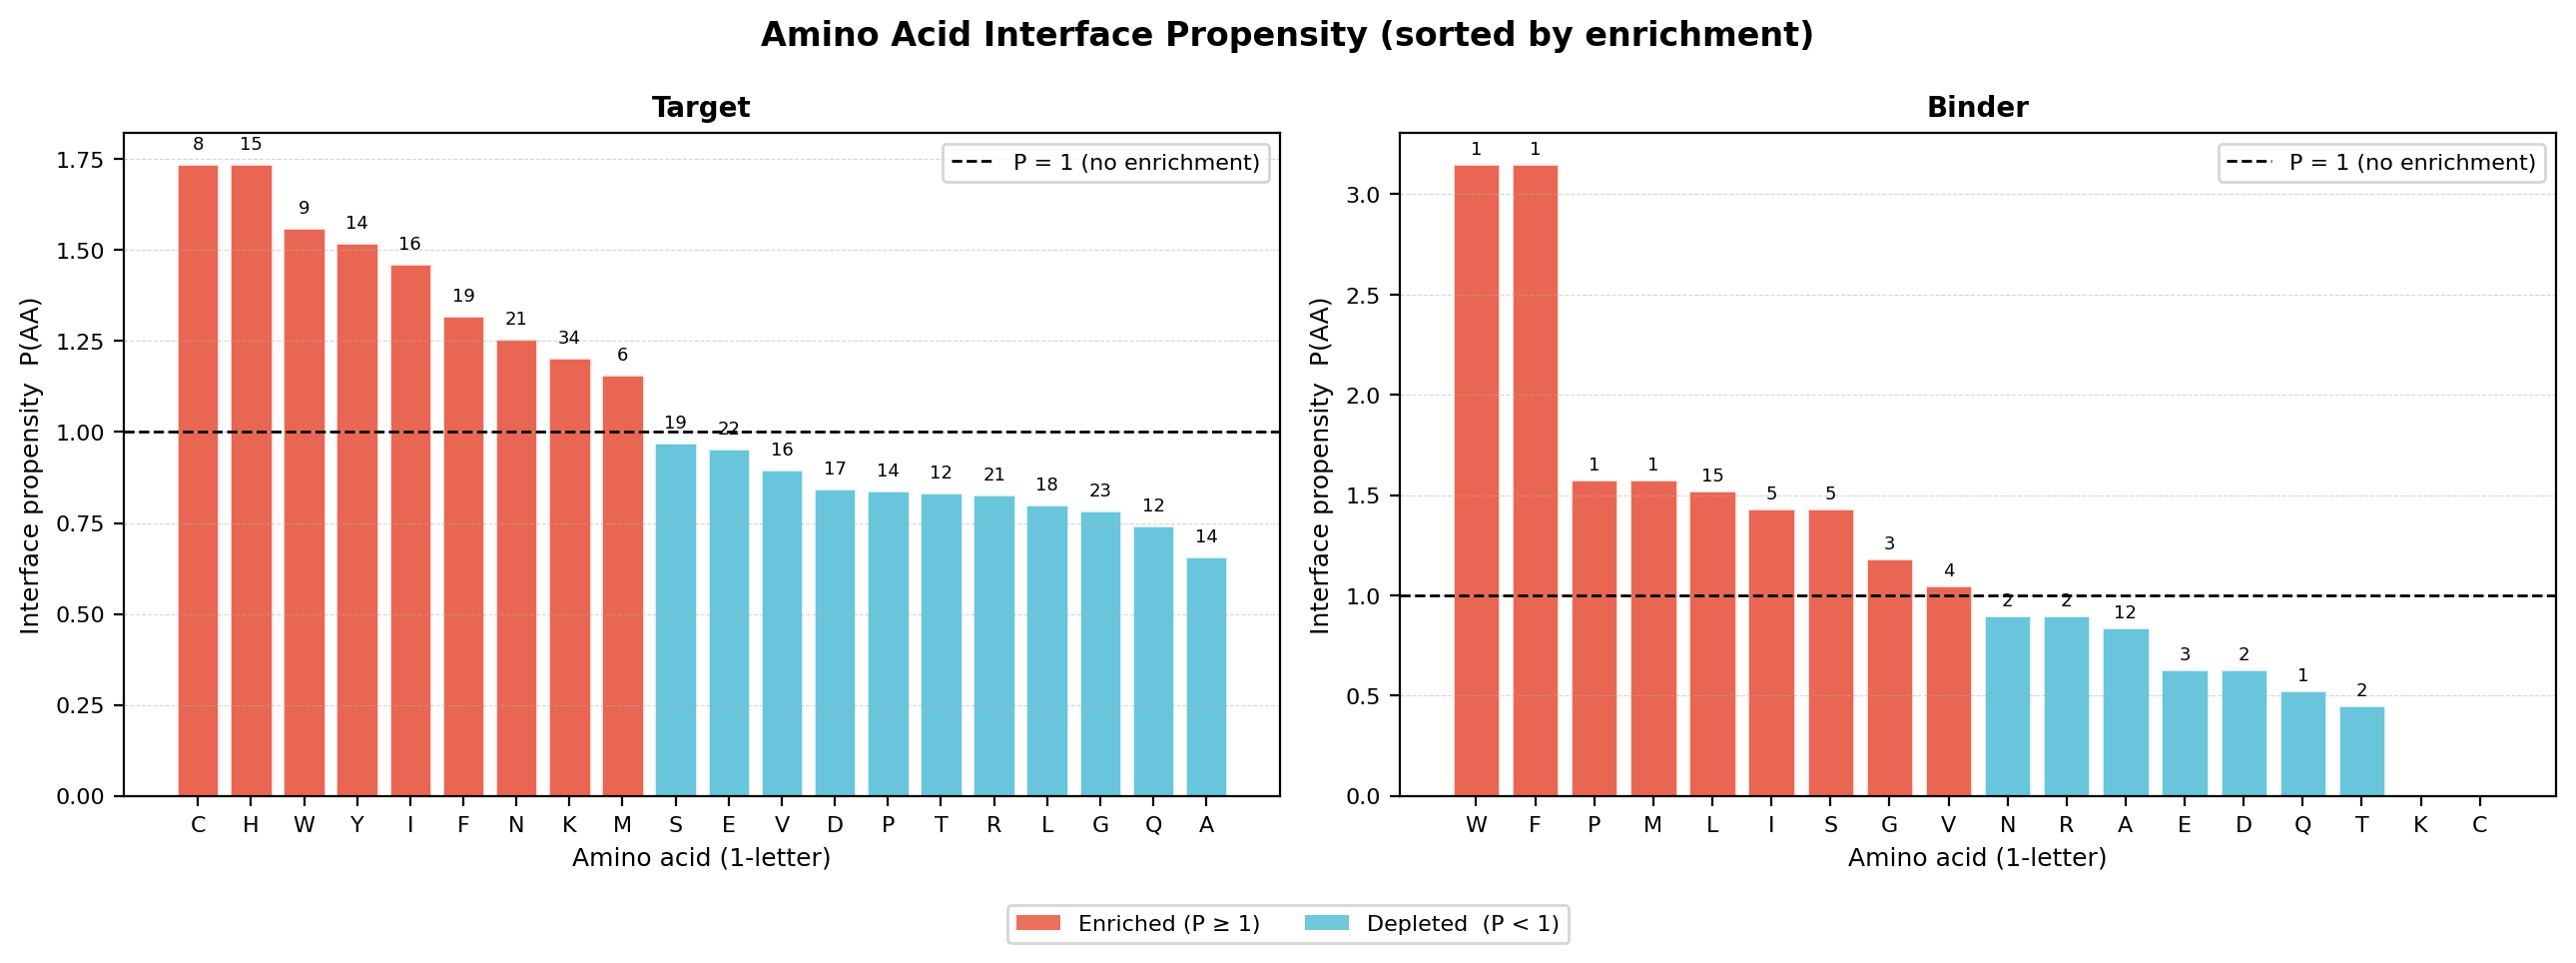

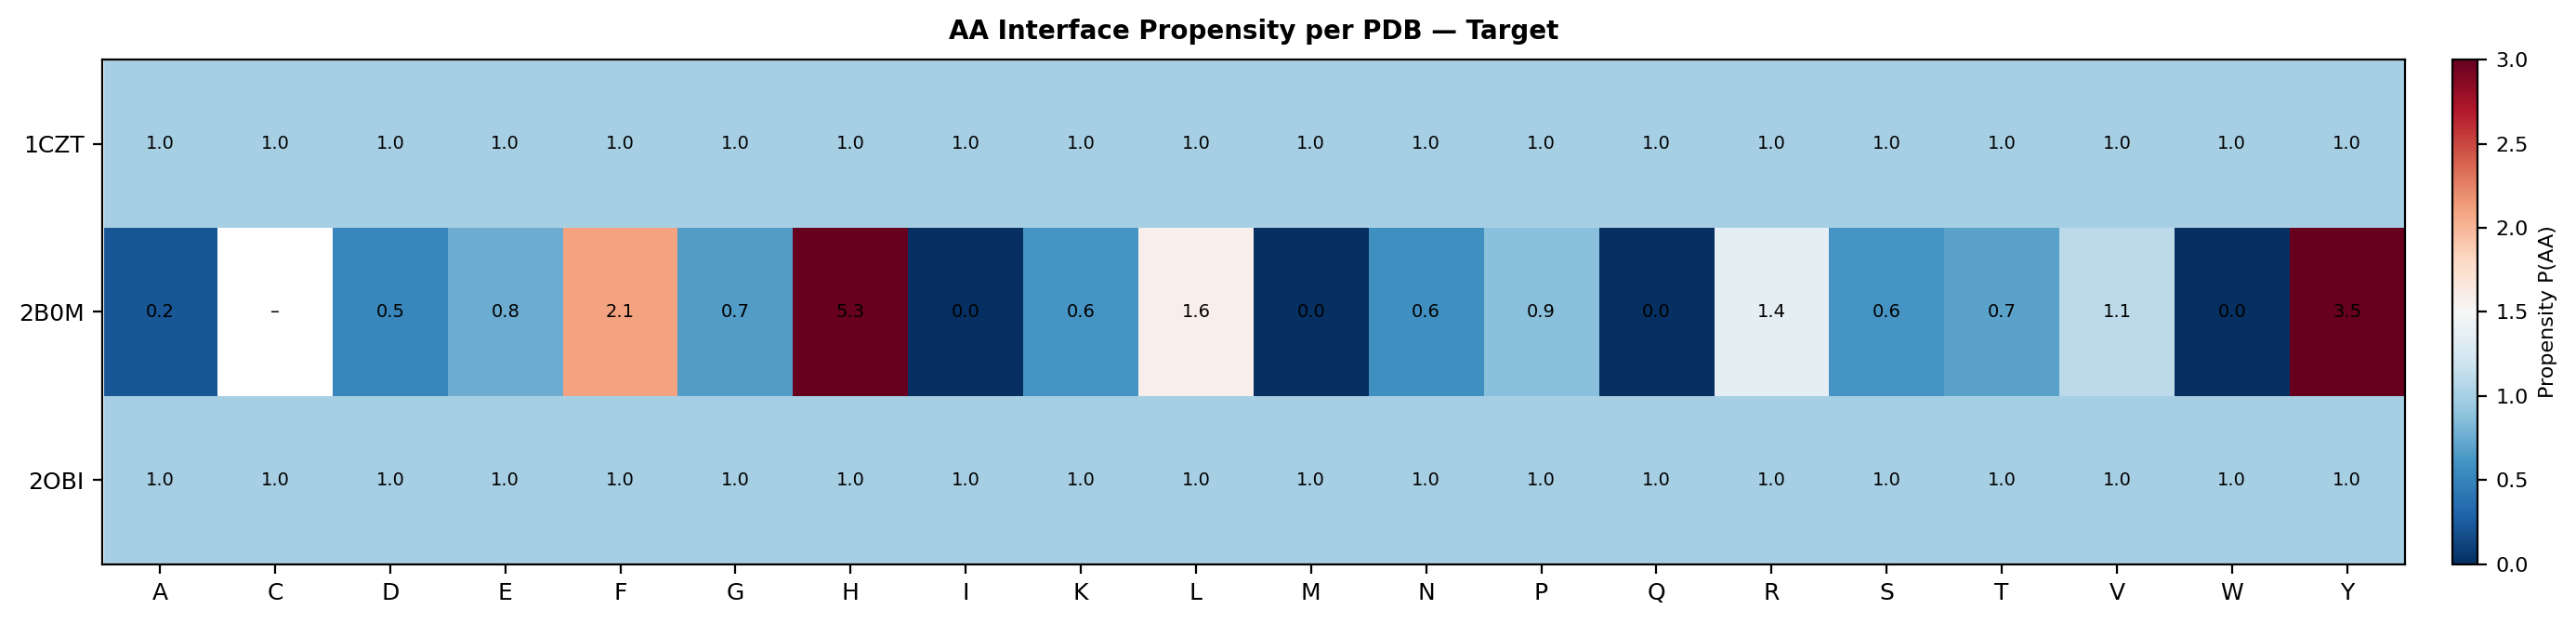

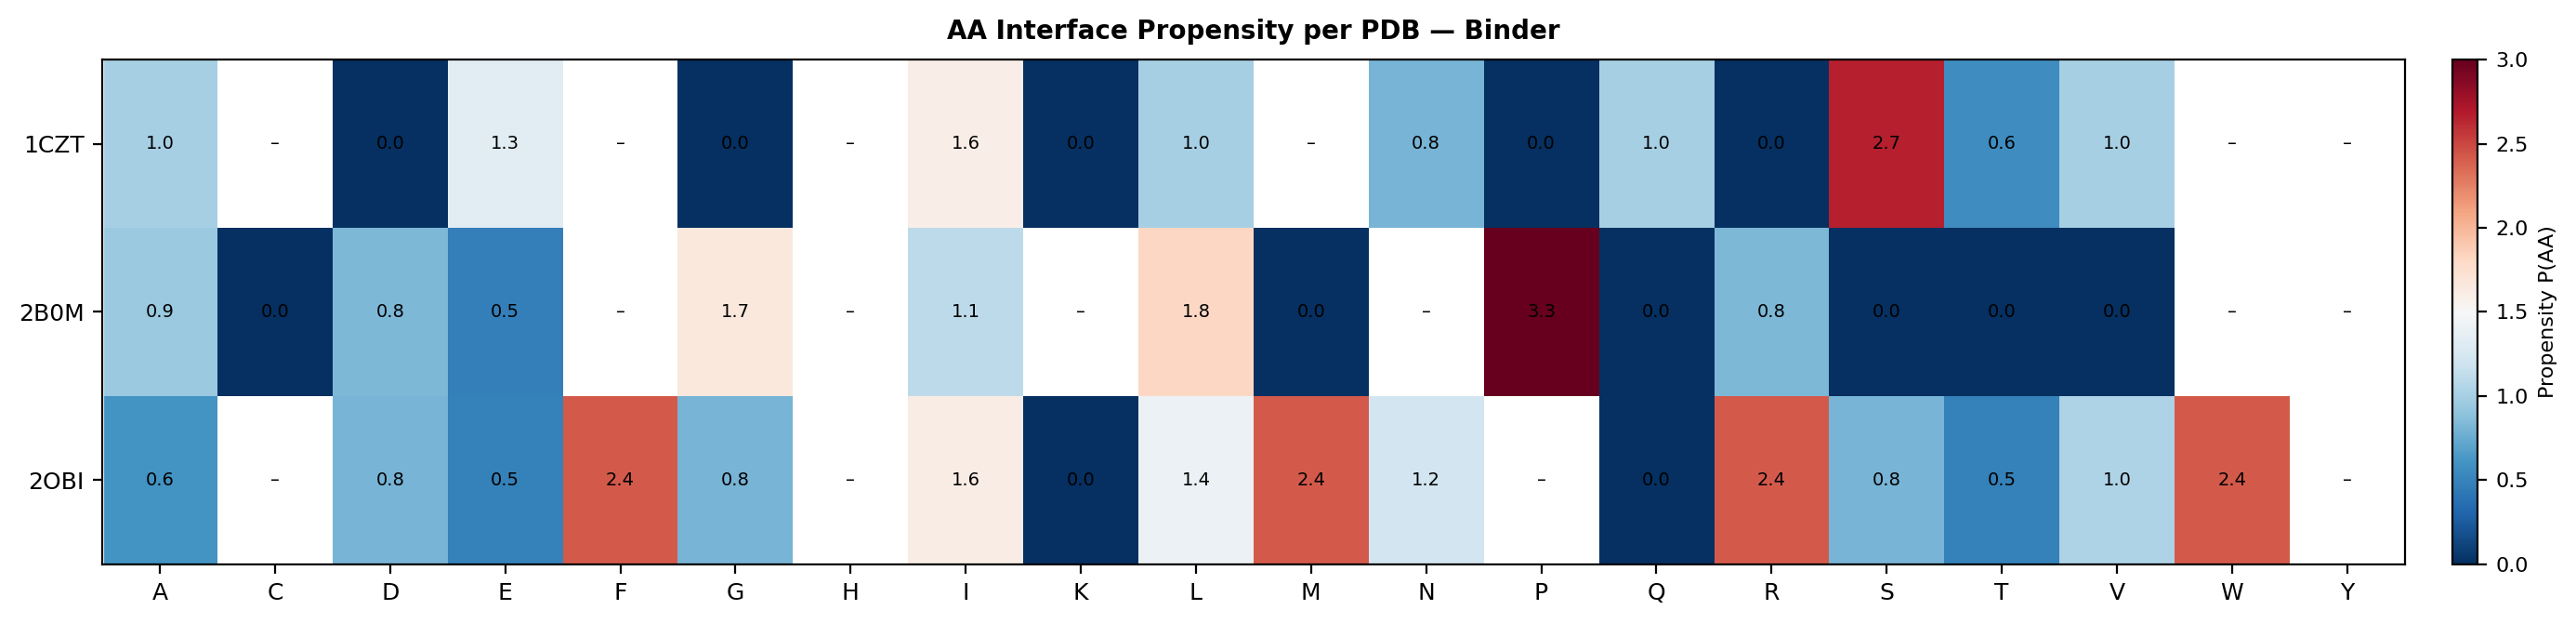

In [40]:
AA3TO1 = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
    'HSD': 'H', 'HSE': 'H', 'HSP': 'H', 'MSE': 'M',
}
AA_ORDER = list('ACDEFGHIKLMNPQRSTVWY')  # alphabetical by 1-letter code

# ── residue-level table: one row per unique (pdb_id, role, residue) ──────────
# A residue is flagged interface if ANY of its surface vertices are interface.
res_level = (
    df.groupby(['pdb_id', 'role', 'residue'])['is_interface']
    .any()
    .reset_index()
)
res_level['aa3'] = res_level['residue'].str.split('_').str[0]
res_level['aa1'] = res_level['aa3'].map(AA3TO1).fillna('?')

# ── compute propensity pooled across all PDB entries ─────────────────────────
prop_rows = []
for role in ['target', 'binder']:
    sub        = res_level[res_level.role == role]
    total_res  = len(sub)
    iface_res  = sub.is_interface.sum()

    for aa1 in AA_ORDER:
        aa_sub  = sub[sub.aa1 == aa1]
        n_surf  = len(aa_sub)           # total unique residues of this type on surface
        n_iface = aa_sub.is_interface.sum()

        f_surf  = n_surf  / total_res if total_res  > 0 else 0
        f_iface = n_iface / iface_res if iface_res > 0 else 0
        prop    = f_iface / f_surf if f_surf > 0 else np.nan

        prop_rows.append({
            'role':        role,
            'aa':          aa1,
            'n_surface':   int(n_surf),
            'n_interface': int(n_iface),
            'f_surface':   round(f_surf,  4),
            'f_interface': round(f_iface, 4),
            'propensity':  round(prop, 4) if not np.isnan(prop) else np.nan,
        })

prop_df = pd.DataFrame(prop_rows)
print(prop_df.to_string(index=False))
prop_df.to_csv(os.path.join(OUT_DIR, 'aa_propensity.csv'), index=False)

# ── Fig 7 : AA frequency at interface vs. full surface ───────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

for ax, role in zip(axes, ['target', 'binder']):
    sub  = prop_df[prop_df.role == role].set_index('aa').reindex(AA_ORDER)
    x    = np.arange(len(AA_ORDER))
    w    = 0.38
    bars_s = ax.bar(x - w/2, sub['f_surface'],   w, label='Full surface',  color='#4DBBD5', alpha=0.85)
    bars_i = ax.bar(x + w/2, sub['f_interface'], w, label='Interface',     color='#E64B35', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(AA_ORDER, fontsize=8)
    ax.set_ylabel('Residue fraction')
    ax.set_title(f'{role.capitalize()} — AA composition: full surface vs. interface', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linewidth=0.4, linestyle='--', alpha=0.5)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

fig.suptitle('Amino Acid Composition at Interface vs. Full Surface',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig7_aa_composition.png'), bbox_inches='tight', dpi=200)
plt.show()

# ── Fig 8 : Propensity bar chart sorted by enrichment ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, role in zip(axes, ['target', 'binder']):
    sub = (
        prop_df[prop_df.role == role]
        .dropna(subset=['propensity'])
        .sort_values('propensity', ascending=False)
    )
    colors = ['#E64B35' if p >= 1 else '#4DBBD5' for p in sub['propensity']]
    bars = ax.bar(sub['aa'], sub['propensity'], color=colors, alpha=0.85, edgecolor='white')

    ax.axhline(1.0, color='black', linewidth=1.0, linestyle='--', label='P = 1 (no enrichment)')
    ax.set_xlabel('Amino acid (1-letter)')
    ax.set_ylabel('Interface propensity  P(AA)')
    ax.set_title(f'{role.capitalize()}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linewidth=0.4, linestyle='--', alpha=0.5)

    # annotate n_interface count above each bar
    for bar, (_, row) in zip(bars, sub.iterrows()):
        if row['n_interface'] > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.03,
                    str(int(row['n_interface'])),
                    ha='center', va='bottom', fontsize=6.5)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#E64B35', alpha=0.8, label='Enriched (P ≥ 1)'),
    Patch(facecolor='#4DBBD5', alpha=0.8, label='Depleted  (P < 1)'),
], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.06))
fig.suptitle('Amino Acid Interface Propensity (sorted by enrichment)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig8_aa_propensity.png'), bbox_inches='tight', dpi=200)
plt.show()

# ── Fig 9 : Propensity heatmap — per PDB entry ───────────────────────────────
pdb_prop_rows = []
for pdb_id in df['pdb_id'].unique():
    for role in ['target', 'binder']:
        sub       = res_level[(res_level.pdb_id == pdb_id) & (res_level.role == role)]
        total_res = len(sub)
        iface_res = sub.is_interface.sum()
        for aa1 in AA_ORDER:
            aa_sub  = sub[sub.aa1 == aa1]
            n_surf  = len(aa_sub)
            n_iface = aa_sub.is_interface.sum()
            f_surf  = n_surf  / total_res if total_res  > 0 else 0
            f_iface = n_iface / iface_res if iface_res > 0 else 0
            prop    = f_iface / f_surf if f_surf > 0 else np.nan
            pdb_prop_rows.append({'pdb_id': pdb_id, 'role': role, 'aa': aa1, 'propensity': prop})

pdb_prop = pd.DataFrame(pdb_prop_rows)

for role in ['target', 'binder']:
    sub = pdb_prop[pdb_prop.role == role]
    hm  = sub.pivot(index='pdb_id', columns='aa', values='propensity').reindex(columns=AA_ORDER)

    fig, ax = plt.subplots(figsize=(14, len(hm) * 0.75 + 1.2))
    im = ax.imshow(hm.values, aspect='auto', cmap='RdBu_r', vmin=0, vmax=3)
    ax.set_xticks(range(len(AA_ORDER)));  ax.set_xticklabels(AA_ORDER, fontsize=9)
    ax.set_yticks(range(len(hm)));        ax.set_yticklabels(hm.index, fontsize=9)
    for r in range(len(hm)):
        for c in range(len(AA_ORDER)):
            v = hm.iloc[r, c]
            txt = f'{v:.1f}' if not np.isnan(v) else '–'
            ax.text(c, r, txt, ha='center', va='center', fontsize=7)
    cb = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cb.set_label('Propensity P(AA)', fontsize=8)
    ax.axvline(x=-0.5, color='white')
    ax.set_title(f'AA Interface Propensity per PDB — {role.capitalize()}',
                 fontweight='bold', pad=8)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f'fig6_aa_propensity_heatmap_{role}.png'),
                bbox_inches='tight', dpi=200)
    plt.show()

pdb_prop.to_csv(os.path.join(OUT_DIR, 'aa_propensity_per_pdb.csv'), index=False)

## Output Summary

In [41]:
print(f"Outputs saved to: {os.path.abspath(OUT_DIR)}\n")
for f in sorted(os.listdir(OUT_DIR)):
    kb = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
    print(f"  {f:<52}  {kb:6.1f} KB")

Outputs saved to: /mnt/e/pmp_targeted_drug/dryad/interfacial_feat/analysis_output

  aa_propensity.csv                                        1.4 KB
  aa_propensity_per_pdb.csv                                2.7 KB
  fig1_iface_vs_surface.png                              245.1 KB
  fig2_interface_histograms.png                          232.2 KB
  fig3_binder_profile.png                                 83.1 KB
  fig3_target_profile.png                                 82.1 KB
  fig4_feature_correlation.png                            82.6 KB
  fig5_radar_chart.png                                   184.8 KB
  fig6_aa_propensity_heatmap_binder.png                   63.6 KB
  fig6_aa_propensity_heatmap_target.png                   58.8 KB
  fig7_aa_composition.png                                113.6 KB
  fig8_aa_propensity.png                                 112.4 KB
  interface_feature_stats.csv                              1.2 KB
  interface_residue_counts.csv                             